In [46]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu
df = pd.read_csv("./data/root_data/airbnb/berlin_weekends.csv")

# Xem nhanh thông tin dữ liệu
print(df.head())
print(df.info())


   Unnamed: 0     realSum        room_type  room_shared  room_private  \
0           0  185.799757     Private room        False          True   
1           1  387.491820  Entire home/apt        False         False   
2           2  194.914462     Private room        False          True   
3           3  171.777134     Private room        False          True   
4           4  207.768533     Private room        False          True   

   person_capacity  host_is_superhost  multi  biz  cleanliness_rating  \
0                2               True      0    0                10.0   
1                6              False      0    1                10.0   
2                5              False      0    1                 9.0   
3                2              False      0    0                 9.0   
4                3               True      0    0                10.0   

   guest_satisfaction_overall  bedrooms      dist  metro_dist  attr_index  \
0                        98.0         1  3.58

In [47]:
# Mã hóa room_type để dùng làm feature (không phải target)
df['room_type'] = df['room_type'].map({
    'Entire home/apt': 0,
    'Private room': 1,
    'Shared room': 2
})

# Chuyển đổi Boolean sang số
bool_cols = ['room_shared', 'room_private', 'host_is_superhost']
df[bool_cols] = df[bool_cols].astype(int)


In [48]:
median_price = df['realSum'].median()
df['price_category'] = df['realSum'].apply(lambda x: 'High' if x > median_price else 'Low')

print(df['price_category'].value_counts())


price_category
Low     600
High    600
Name: count, dtype: int64


In [49]:
def cap_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[column] = np.clip(df[column], lower, upper)
    return df

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop(['room_type'])
for col in numeric_cols:
    df = cap_outliers(df, col)


In [50]:
skewed = ['dist', 'metro_dist']
for col in skewed:
    df[col] = np.log1p(df[col])


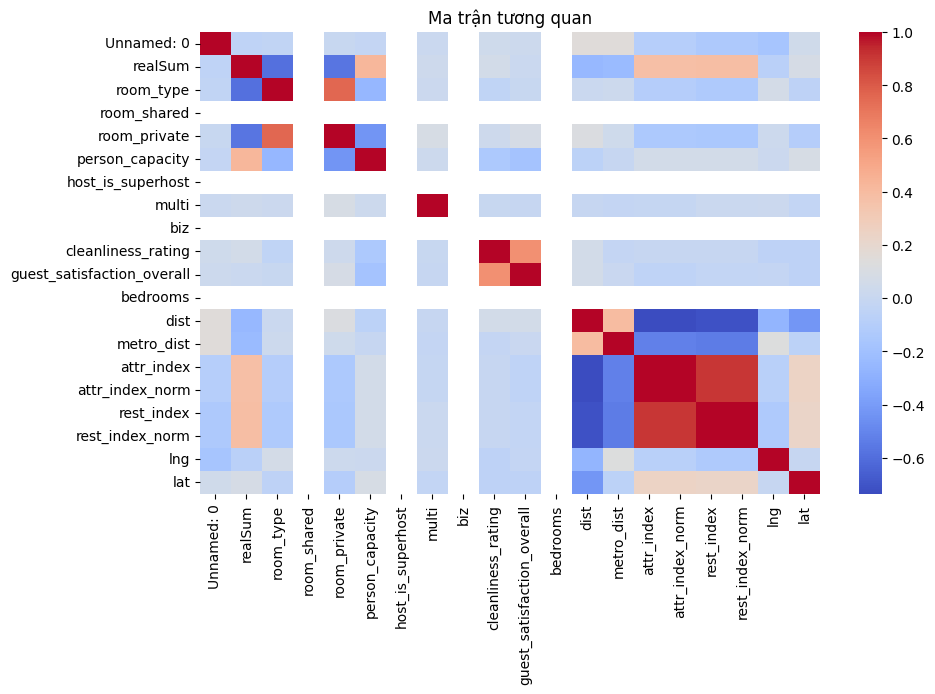

In [51]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Ma trận tương quan")
plt.show()

df = df.drop(columns=['attr_index_norm', 'rest_index_norm'])


In [52]:
X = df.drop(columns=['realSum', 'price_category'])
y = df['price_category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (960, 17) Test: (240, 17)


In [53]:
cart = DecisionTreeClassifier(random_state=42)
cart.fit(X_train, y_train)

# Dự đoán
y_pred_train = cart.predict(X_train)
y_pred_test = cart.predict(X_test)

print("🎯 Kết quả trước khi cắt tỉa:")
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("\nClassification Report (Train):\n", classification_report(y_train, y_pred_train))
print("\nClassification Report (Test):\n", classification_report(y_test, y_pred_test))


🎯 Kết quả trước khi cắt tỉa:
Train Accuracy: 1.0
Test Accuracy: 0.75

Classification Report (Train):
               precision    recall  f1-score   support

        High       1.00      1.00      1.00       480
         Low       1.00      1.00      1.00       480

    accuracy                           1.00       960
   macro avg       1.00      1.00      1.00       960
weighted avg       1.00      1.00      1.00       960


Classification Report (Test):
               precision    recall  f1-score   support

        High       0.75      0.75      0.75       120
         Low       0.75      0.75      0.75       120

    accuracy                           0.75       240
   macro avg       0.75      0.75      0.75       240
weighted avg       0.75      0.75      0.75       240



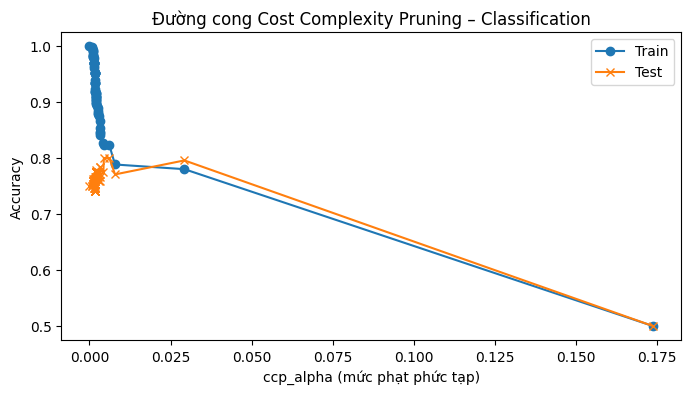

Alpha tối ưu: 0.004453902840561537


In [54]:
path = cart.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

train_acc, test_acc = [], []
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)
    train_acc.append(model.score(X_train, y_train))
    test_acc.append(model.score(X_test, y_test))

# Vẽ đường cong để chọn alpha tối ưu
plt.figure(figsize=(8,4))
plt.plot(ccp_alphas, train_acc, marker='o', label='Train')
plt.plot(ccp_alphas, test_acc, marker='x', label='Test')
plt.xlabel("ccp_alpha (mức phạt phức tạp)")
plt.ylabel("Accuracy")
plt.title("Đường cong Cost Complexity Pruning – Classification")
plt.legend()
plt.show()

best_alpha = ccp_alphas[np.argmax(test_acc)]
print("Alpha tối ưu:", best_alpha)


In [55]:
best_cart = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
best_cart.fit(X_train, y_train)

# Dự đoán lại
y_train_best = best_cart.predict(X_train)
y_test_best = best_cart.predict(X_test)

print("\n🎯 Kết quả sau khi cắt tỉa:")
print("Train Accuracy:", accuracy_score(y_train, y_train_best))
print("Test Accuracy:", accuracy_score(y_test, y_test_best))
print("\nClassification Report (Train):\n", classification_report(y_train, y_train_best))
print("\nClassification Report (Test):\n", classification_report(y_test, y_test_best))

print("\nSố lá trước cắt tỉa:", cart.get_n_leaves())
print("Số lá sau cắt tỉa:", best_cart.get_n_leaves())



🎯 Kết quả sau khi cắt tỉa:
Train Accuracy: 0.8229166666666666
Test Accuracy: 0.8

Classification Report (Train):
               precision    recall  f1-score   support

        High       0.86      0.77      0.81       480
         Low       0.79      0.88      0.83       480

    accuracy                           0.82       960
   macro avg       0.83      0.82      0.82       960
weighted avg       0.83      0.82      0.82       960


Classification Report (Test):
               precision    recall  f1-score   support

        High       0.84      0.74      0.79       120
         Low       0.77      0.86      0.81       120

    accuracy                           0.80       240
   macro avg       0.80      0.80      0.80       240
weighted avg       0.80      0.80      0.80       240


Số lá trước cắt tỉa: 156
Số lá sau cắt tỉa: 6


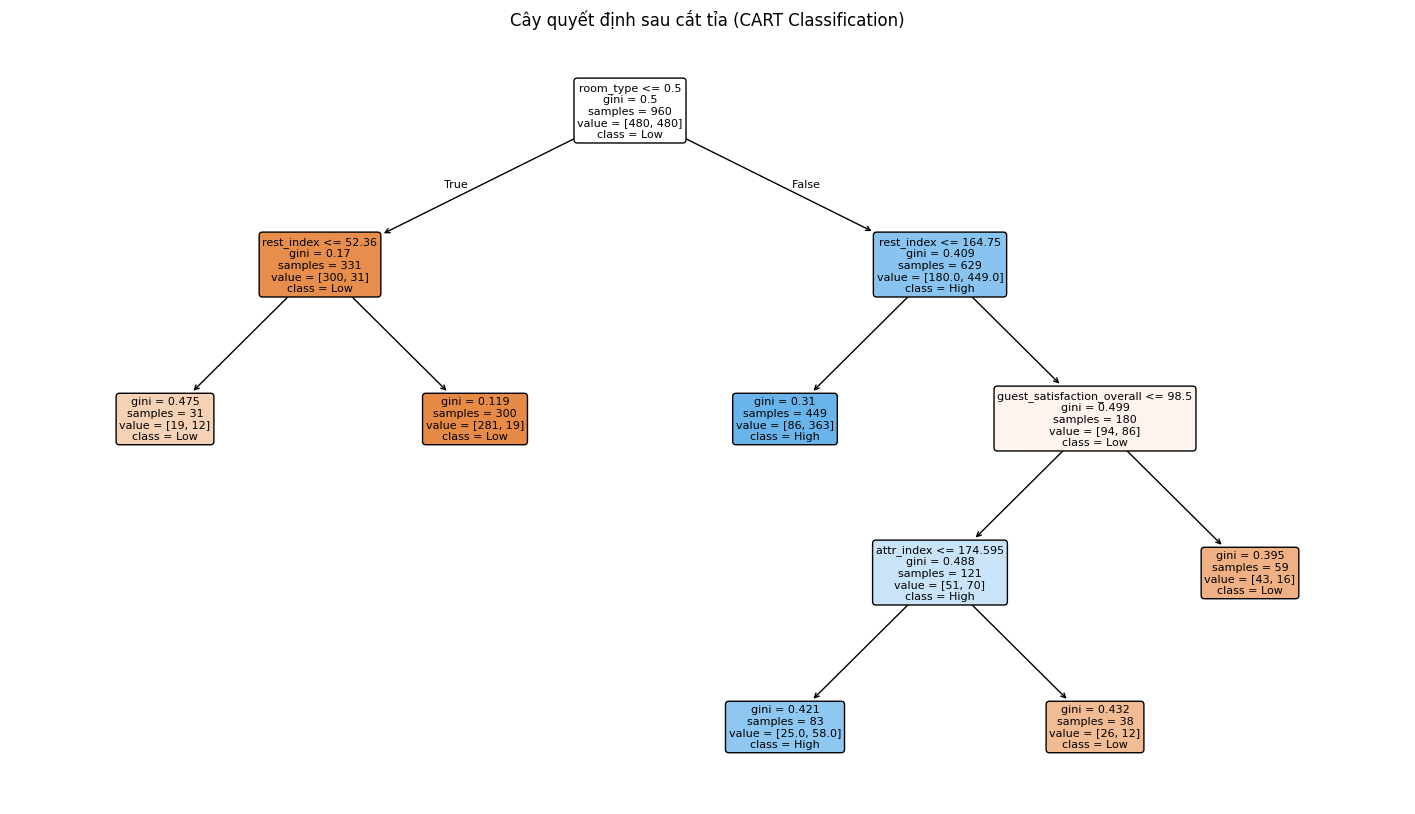

Số lá trước cắt tỉa: 156
Số lá sau cắt tỉa: 6


In [56]:
plt.figure(figsize=(18,10))
plot_tree(best_cart, feature_names=X.columns, class_names=['Low', 'High'],
          filled=True, rounded=True, fontsize=8)
plt.title("Cây quyết định sau cắt tỉa (CART Classification)")
plt.show()

print("Số lá trước cắt tỉa:", cart.get_n_leaves())
print("Số lá sau cắt tỉa:", best_cart.get_n_leaves())


In [57]:
params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'ccp_alpha': [0.0, 0.001, 0.005, 0.01]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=params,
    cv=5,
    scoring='accuracy'
)
grid.fit(X_train, y_train)

print("🔍 Best params:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)


🔍 Best params: {'ccp_alpha': 0.005, 'max_depth': 7, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV accuracy: 0.79375
